# 03 — Baseline ML (no hyper-parameter tuning)

**Goal:** establish bottom-line performance for 12 scenarios before any optimisation.

| Axis | Options |
|------|---------|
| Model | LogisticRegression, MultinomialNB, LinearSVC |
| Features | BoW, TF-IDF unigram+bigram |
| Class imbalance | None, Balanced |

> **Rules:** fit on `train` only → evaluate on `dev`. Test set is **untouched**.

## 1. Setup & Imports

In [3]:
import sys, time, json, pickle, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_sample_weight

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from configs.config import PATHS, LABEL_MAP, LABEL_COLORS
from src.features  import load_feature_matrix
from src.evaluate  import (
    evaluate_model, plot_confusion_matrix,
    save_predictions, compare_models, plot_model_comparison,
)

sns.set_theme(style='whitegrid')
warnings.filterwarnings('ignore')
RANDOM_STATE = 42
FIG_DIR = Path(PATHS['figures_dir'])
FIG_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load feature matrices

In [4]:
X_tr_bow,   y_train = load_feature_matrix('train', 'bow')
X_tr_tfidf, _       = load_feature_matrix('train', 'tfidf_unibi')
X_dv_bow,   y_dev   = load_feature_matrix('dev',   'bow')
X_dv_tfidf, _       = load_feature_matrix('dev',   'tfidf_unibi')

print('train bow      :', X_tr_bow.shape,   '| y:', y_train.shape)
print('train tfidf_ub :', X_tr_tfidf.shape)
print('dev   bow      :', X_dv_bow.shape,   '| y:', y_dev.shape)
print('dev   tfidf_ub :', X_dv_tfidf.shape)
print()
unique, counts = np.unique(y_train, return_counts=True)
print('Train label dist:', dict(zip([LABEL_MAP[i] for i in unique], counts)))
print('Dev   label dist:', dict(zip([LABEL_MAP[i] for i in unique],
                                    np.unique(y_dev, return_counts=True)[1])))

train bow      : (24048, 8749) | y: (24048,)
train tfidf_ub : (24048, 10000)
dev   bow      : (2672, 8749) | y: (2672,)
dev   tfidf_ub : (2672, 10000)

Train label dist: {'CLEAN': np.int64(19886), 'OFFENSIVE': np.int64(1606), 'HATE': np.int64(2556)}
Dev   label dist: {'CLEAN': np.int64(2190), 'OFFENSIVE': np.int64(212), 'HATE': np.int64(270)}


## 3. Training scaffold

**Design notes:**

* `LinearSVC` is wrapped with `CalibratedClassifierCV(cv=3)` so we get class
  probabilities for `save_predictions()`. Without this wrapper only
  `decision_function` scores are available.
* `MultinomialNB` has no `class_weight` parameter. For the *Balanced* variant
  we pass `sample_weight=compute_sample_weight('balanced', y_train)` to `fit()`.
  This is mathematically equivalent to upweighting minority classes.
* All other models use `class_weight='balanced'` directly.

In [5]:
FEAT_SETS = {
    'BoW':   (X_tr_bow,   X_dv_bow),
    'TFIDF': (X_tr_tfidf, X_dv_tfidf),
}

def make_model(model_key: str, balanced: bool):
    """Return a freshly-instantiated (unfitted) model."""
    cw = 'balanced' if balanced else None
    if model_key == 'LR':
        return LogisticRegression(
            max_iter=1000, random_state=RANDOM_STATE,
            class_weight=cw, solver='lbfgs',
        )
    if model_key == 'NB':
        return MultinomialNB()       # balanced handled via sample_weight
    if model_key == 'SVC':
        base = LinearSVC(
            max_iter=1000, random_state=RANDOM_STATE,
            class_weight=cw,
        )
        return CalibratedClassifierCV(base, cv=3)
    raise ValueError(f'Unknown model key: {model_key}')


def train_and_evaluate(
    name: str,
    model,
    X_tr, y_tr,
    X_dv, y_dv,
    balanced_nb: bool = False,
) -> dict:
    """Fit model, time it, evaluate on dev, return metrics dict."""
    # --- fit ---
    t0 = time.perf_counter()
    if balanced_nb:
        sw = compute_sample_weight('balanced', y_tr)
        model.fit(X_tr, y_tr, sample_weight=sw)
    else:
        model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    # --- predict ---
    t1 = time.perf_counter()
    y_pred  = model.predict(X_dv)
    inf_time = (time.perf_counter() - t1) / len(y_dv)   # per-sample

    # --- probabilities ---
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_dv)
    else:
        # fallback: one-hot on predicted class
        y_proba = np.zeros((len(y_dv), 3))
        y_proba[np.arange(len(y_dv)), y_pred] = 1.0

    # --- model size (KB) ---
    model_kb = len(pickle.dumps(model)) / 1024

    metrics = evaluate_model(y_dv, y_pred, name,
                             train_time=round(train_time, 3),
                             inference_time=round(inf_time * 1e6, 3))  # µs
    metrics['model_kb']  = round(model_kb, 1)
    metrics['_model']    = model          # keep ref for later
    metrics['_y_pred']   = y_pred
    metrics['_y_proba']  = y_proba
    return metrics

## 4. Train 12 scenarios

In [6]:
SCENARIOS = []
for feat_name, (X_tr, X_dv) in FEAT_SETS.items():
    for model_key, abbrev in [('LR','LR'), ('NB','NB'), ('SVC','SVC')]:
        for balanced in [False, True]:
            bal_label = 'Balanced' if balanced else 'None'
            scenario_name = f'{abbrev}_{feat_name}_{bal_label}'
            SCENARIOS.append((scenario_name, model_key, feat_name,
                              X_tr, X_dv, balanced))

print(f'{len(SCENARIOS)} scenarios to train:',
      [s[0] for s in SCENARIOS])

12 scenarios to train: ['LR_BoW_None', 'LR_BoW_Balanced', 'NB_BoW_None', 'NB_BoW_Balanced', 'SVC_BoW_None', 'SVC_BoW_Balanced', 'LR_TFIDF_None', 'LR_TFIDF_Balanced', 'NB_TFIDF_None', 'NB_TFIDF_Balanced', 'SVC_TFIDF_None', 'SVC_TFIDF_Balanced']


In [7]:
results = {}

for name, model_key, feat_name, X_tr, X_dv, balanced in SCENARIOS:
    model = make_model(model_key, balanced)
    is_balanced_nb = (model_key == 'NB' and balanced)
    print(f'  Training {name} ...', end=' ', flush=True)
    m = train_and_evaluate(
        name, model, X_tr, y_train, X_dv, y_dev,
        balanced_nb=is_balanced_nb,
    )
    results[name] = m
    print(f'f1_macro={m["f1_macro"]:.4f}  train={m["train_time"]:.2f}s  size={m["model_kb"]:.1f}KB')

print(f'\nDone — {len(results)} scenarios.')

  Training LR_BoW_None ... f1_macro=0.5751  train=0.65s  size=205.7KB
  Training LR_BoW_Balanced ... f1_macro=0.5793  train=0.62s  size=205.7KB
  Training NB_BoW_None ... f1_macro=0.5586  train=0.00s  size=410.7KB
  Training NB_BoW_Balanced ... f1_macro=0.5087  train=0.01s  size=410.7KB
  Training SVC_BoW_None ... f1_macro=0.4765  train=2.08s  size=617.2KB
  Training SVC_BoW_Balanced ... f1_macro=0.4685  train=3.13s  size=617.2KB
  Training LR_TFIDF_None ... f1_macro=0.5731  train=0.50s  size=235.1KB
  Training LR_TFIDF_Balanced ... f1_macro=0.6015  train=0.67s  size=235.1KB
  Training NB_TFIDF_None ... f1_macro=0.4122  train=0.00s  size=469.4KB
  Training NB_TFIDF_Balanced ... f1_macro=0.5100  train=0.01s  size=469.4KB
  Training SVC_TFIDF_None ... f1_macro=0.5742  train=0.65s  size=705.1KB
  Training SVC_TFIDF_Balanced ... f1_macro=0.5674  train=0.76s  size=705.1KB

Done — 12 scenarios.


## 5. Results comparison table

In [8]:
comp_df = compare_models(results)
display_cols = ['model','features','accuracy','f1_macro',
                'f1_clean','f1_offensive','f1_hate',
                'train_time','inference_time']

# Attach model_kb from results dict
comp_df['model_kb'] = comp_df.apply(
    lambda r: results[f"{r['model']}_{r['features']}_{r['features']}"].get('model_kb',0)
    if f"{r['model']}_{r['features']}_{r['features']}" in results
    else next((results[k]['model_kb'] for k in results
               if k.startswith(f"{r['model']}_{r['features']}")),0),
    axis=1
)

comp_df[display_cols + ['model_kb']]

,model,features,accuracy,f1_macro,f1_clean,f1_offensive,f1_hate,train_time,inference_time,model_kb
0,LR_TFIDF,Balanced,0.7927,0.6015,0.8894,0.3985,0.5166,0.669,0.176,235.1
1,LR_BoW,Balanced,0.7927,0.5793,0.8944,0.3370,0.5066,0.625,0.140,205.7
2,LR_BoW,None,0.8537,0.5751,0.9276,0.3052,0.4925,0.647,0.185,205.7
3,SVC_TFIDF,None,0.8645,0.5742,0.9308,0.2759,0.5158,0.653,1.311,705.1
4,LR_TFIDF,None,0.8623,0.5731,0.9284,0.2738,0.5170,0.496,0.154,235.1
5,SVC_TFIDF,Balanced,0.8630,0.5674,0.9296,0.2568,0.5158,0.756,1.228,705.1
6,NB_BoW,None,0.8439,0.5586,0.9211,0.2353,0.5196,0.003,0.112,410.7
7,NB_TFIDF,Balanced,0.6572,0.5100,0.7834,0.3631,0.3836,0.007,0.107,469.4
8,NB_BoW,Balanced,0.6688,0.5087,0.7956,0.3370,0.3933,0.006,0.118,410.7
9,SVC_BoW,None,0.8466,0.4765,0.9178,0.0611,0.4506,2.085,1.234,617.2


In [9]:
print('=== Full classification report — best scenario ===')
best_name = comp_df.iloc[0]['model'] + '_' + comp_df.iloc[0]['features']
# find actual key
best_key = sorted(results, key=lambda k: results[k]['f1_macro'], reverse=True)[0]
print(f'Best: {best_key}')
print(results[best_key]['classification_report'])

=== Full classification report — best scenario ===
Best: LR_TFIDF_Balanced
              precision    recall  f1-score   support

       CLEAN       0.95      0.84      0.89      2190
   OFFENSIVE       0.33      0.50      0.40       212
        HATE       0.42      0.66      0.52       270

    accuracy                           0.79      2672
   macro avg       0.57      0.67      0.60      2672
weighted avg       0.85      0.79      0.81      2672



## 6. Confusion matrices — top 3 scenarios

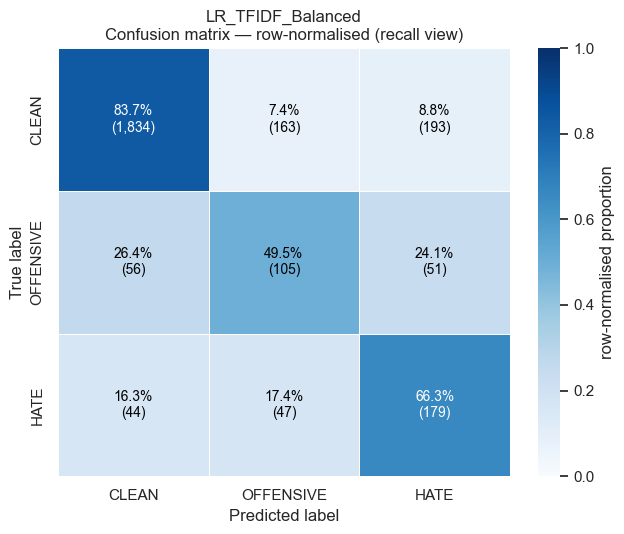

LR_TFIDF_Balanced: f1_macro=0.6015



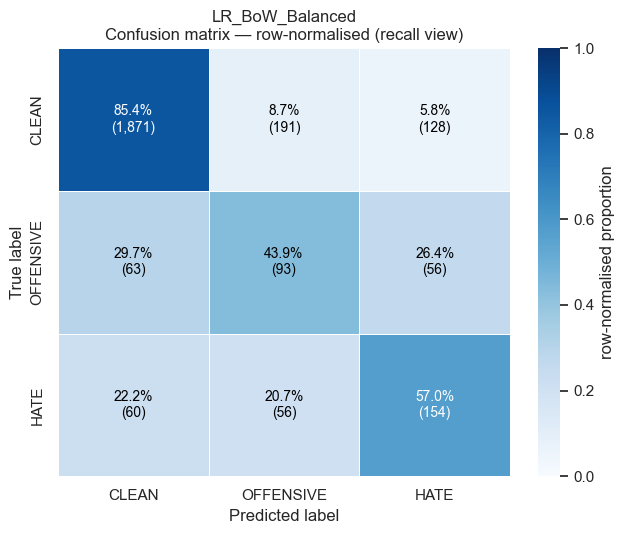

LR_BoW_Balanced: f1_macro=0.5793



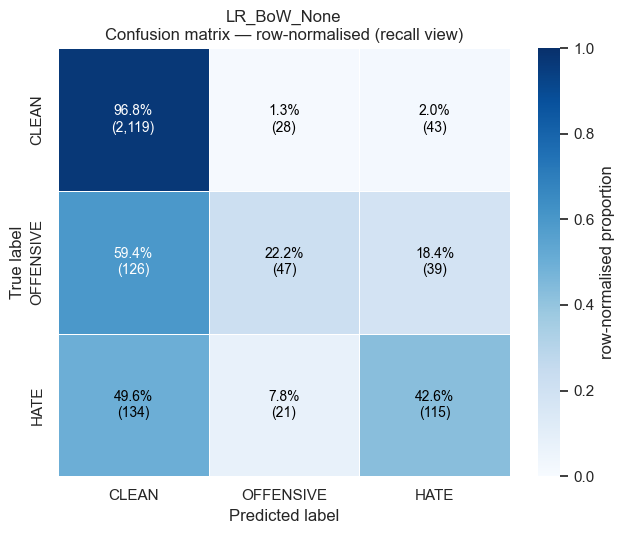

LR_BoW_None: f1_macro=0.5751



In [10]:
top3_keys = sorted(results, key=lambda k: results[k]['f1_macro'], reverse=True)[:3]

for key in top3_keys:
    fig = plot_confusion_matrix(
        y_dev, results[key]['_y_pred'],
        model_name=key,
        save_path=FIG_DIR / f'cm_{key}.png',
        normalize=True,
    )
    plt.show()
    print(f'{key}: f1_macro={results[key]["f1_macro"]:.4f}')
    print()

## 7. Visual comparison

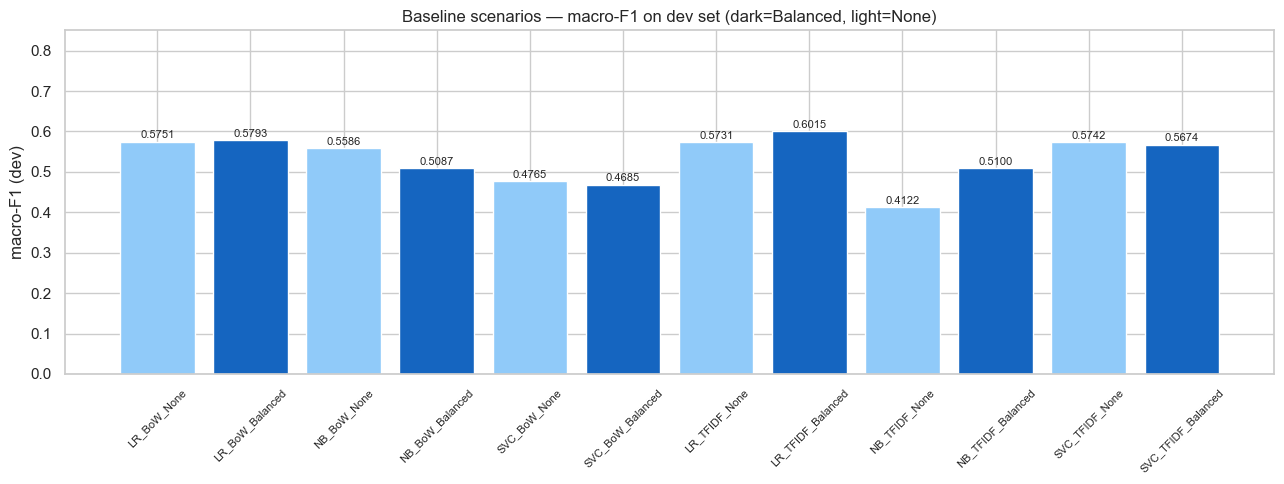

In [11]:
# ── f1_macro for all 12 scenarios ──────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
scenario_names = list(results.keys())
f1_values      = [results[k]['f1_macro'] for k in scenario_names]
colors = ['#1565C0' if 'Balanced' in k else '#90CAF9' for k in scenario_names]
bars = ax.bar(scenario_names, f1_values, color=colors, edgecolor='white')
for b, v in zip(bars, f1_values):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 0.85)
ax.set_ylabel('macro-F1 (dev)')
ax.set_title('Baseline scenarios — macro-F1 on dev set (dark=Balanced, light=None)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'baseline_f1macro_all.png', dpi=150, bbox_inches='tight')
plt.show()

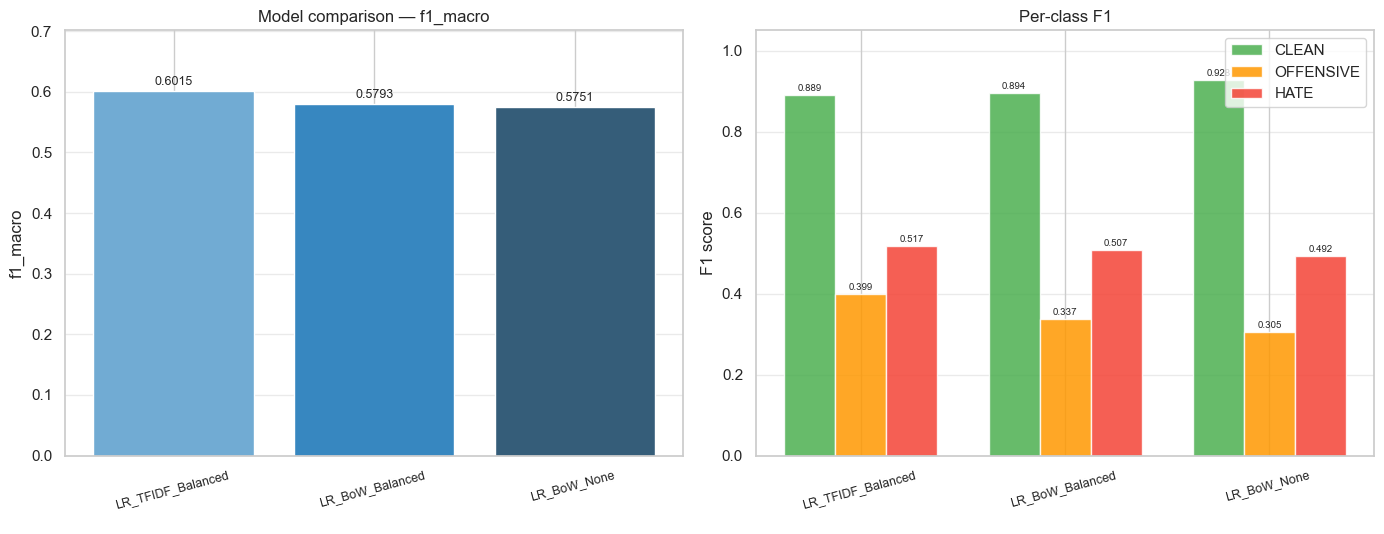

In [12]:
# ── per-class F1 for top 3 ──────────────────────────────
top3_df = comp_df.head(3).copy()
top3_df['model'] = top3_keys          # use full scenario name
top3_df['features'] = ''

fig = plot_model_comparison(
    top3_df, metric='f1_macro',
    save_path=FIG_DIR / 'baseline_top3_comparison.png',
)
plt.show()

## 8. Summary & Key Insights

In [13]:
print('=' * 65)
print('TOP 3 SCENARIOS (by macro-F1 on dev)')
print('=' * 65)
for i, key in enumerate(top3_keys, 1):
    m = results[key]
    print(f'{i}. {key:<30}  f1_macro={m["f1_macro"]:.4f}'
          f'  f1_off={m["f1_offensive"]:.4f}  f1_hate={m["f1_hate"]:.4f}'
          f'  train={m["train_time"]:.2f}s  {m["model_kb"]:.0f}KB')

print()
print('SPEED / F1 TRADE-OFF (f1_macro > 0.55, sorted by train_time)')
print('-' * 65)
fast = [(k, results[k]) for k in results
        if results[k]['f1_macro'] > 0.55]
fast.sort(key=lambda x: x[1]['train_time'])
for k, m in fast[:5]:
    print(f'  {k:<30}  f1_macro={m["f1_macro"]:.4f}'
          f'  train={m["train_time"]:.2f}s')

print()
print('WEAKEST CLASS PER TOP-3 SCENARIO')
print('-' * 65)
for key in top3_keys:
    m = results[key]
    per_class = {'CLEAN': m['f1_clean'],
                 'OFFENSIVE': m['f1_offensive'],
                 'HATE': m['f1_hate']}
    weakest = min(per_class, key=per_class.get)
    print(f'  {key:<30}  weakest={weakest} ({per_class[weakest]:.4f})')

TOP 3 SCENARIOS (by macro-F1 on dev)
1. LR_TFIDF_Balanced               f1_macro=0.6015  f1_off=0.3985  f1_hate=0.5166  train=0.67s  235KB
2. LR_BoW_Balanced                 f1_macro=0.5793  f1_off=0.3370  f1_hate=0.5066  train=0.62s  206KB
3. LR_BoW_None                     f1_macro=0.5751  f1_off=0.3052  f1_hate=0.4925  train=0.65s  206KB

SPEED / F1 TRADE-OFF (f1_macro > 0.55, sorted by train_time)
-----------------------------------------------------------------
  NB_BoW_None                     f1_macro=0.5586  train=0.00s
  LR_TFIDF_None                   f1_macro=0.5731  train=0.50s
  LR_BoW_Balanced                 f1_macro=0.5793  train=0.62s
  LR_BoW_None                     f1_macro=0.5751  train=0.65s
  SVC_TFIDF_None                  f1_macro=0.5742  train=0.65s

WEAKEST CLASS PER TOP-3 SCENARIO
-----------------------------------------------------------------
  LR_TFIDF_Balanced               weakest=OFFENSIVE (0.3985)
  LR_BoW_Balanced                 weakest=OFFENSIVE (

## 9. Save results to JSON

In [14]:
import numpy as np

_SKIP = {'confusion_matrix', '_model', '_y_pred', '_y_proba'}

def _json_safe(obj):
    if isinstance(obj, (np.integer, np.int32, np.int64)): return int(obj)
    if isinstance(obj, (np.floating, np.float32, np.float64)): return float(obj)
    if isinstance(obj, np.ndarray): return obj.tolist()
    return obj

save_dict = {}
for name, m in results.items():
    save_dict[name] = {k: _json_safe(v) for k, v in m.items() if k not in _SKIP}
    # keep confusion matrix as nested list
    save_dict[name]['confusion_matrix'] = m['confusion_matrix'].tolist()

out_path = Path(PATHS['results_dir']) / 'baseline_no_tuning.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(save_dict, f, indent=2, ensure_ascii=False)

print(f'Saved → {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)')
print(f'Scenarios saved: {list(save_dict.keys())}')

Saved → d:\Graduation Project\results\baseline_no_tuning.json  (16.8 KB)
Scenarios saved: ['LR_BoW_None', 'LR_BoW_Balanced', 'NB_BoW_None', 'NB_BoW_Balanced', 'SVC_BoW_None', 'SVC_BoW_Balanced', 'LR_TFIDF_None', 'LR_TFIDF_Balanced', 'NB_TFIDF_None', 'NB_TFIDF_Balanced', 'SVC_TFIDF_None', 'SVC_TFIDF_Balanced']


## ✅ Week-3 Baseline Checklist

- [x] 12 scenarios trained on `train` only.
- [x] Evaluated on `dev` with macro-F1 as primary metric.
- [x] `MultinomialNB` balanced variant uses `sample_weight` (no leakage).
- [x] `LinearSVC` wrapped with `CalibratedClassifierCV` for probabilities.
- [x] Training time, inference time (µs/sample), model size (KB) logged.
- [x] Confusion matrices for top 3 saved under `results/figures/`.
- [x] Results persisted to `results/baseline_no_tuning.json`.
- [ ] Test set: **untouched**.

**Next — Week 4:** Hyper-parameter tuning (GridSearch / Optuna) on the
top-2 model types from this baseline.